In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sparrow as sp
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import matplotlib.pyplot as plt


the value of the environment variable BASIC_DCT_BACKEND is not in ["JAX","SCIPY"]
2024-11-21 17:26:11,049 - sparrow.image.pixel_clustering._clustering - WARNING - 'flowsom' not installed, 'sp.im.flowsom' will not be available.
2024-11-21 17:26:11,068 - sparrow.table.cell_clustering._clustering - WARNING - 'flowsom' not installed, 'sp.tb.flowsom' will not be available.
2024-11-21 17:26:11,082 - sparrow.plot - WARNING - 'joypy' not installed, 'sp.pl.ridgeplot_channel' and 'sp.pl.ridgeplot_channel_sample' will not be available.
2024-11-21 17:26:11,083 - sparrow.plot - WARNING - 'textalloc' not installed, 'sp.pl.group_snr_ratio' and 'sp.pl.snr_ratio' will not be available.


In [4]:
sdata = spatialdata_io.visium_hd('../data/Visium_HD_MouseBrain/',
                                 fullres_image_file="microscope_image/Visium_HD_Mouse_Brain_tissue_image.tif")
                                 #annotate_table_by_labels=True)
                                 
for table in sdata.tables.values():
    table.var_names_make_unique()


/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
sdata

SpatialData object
├── Images
│     ├── 'Visium_HD_Mouse_Brain_full_image': DataTree[cyx] (3, 23947, 18872), (3, 11973, 9436), (3, 5986, 4718), (3, 2993, 2359), (3, 1496, 1179)
│     ├── 'Visium_HD_Mouse_Brain_hires_image': DataArray[cyx] (3, 6000, 4729)
│     └── 'Visium_HD_Mouse_Brain_lowres_image': DataArray[cyx] (3, 600, 473)
├── Labels
│     ├── 'Visium_HD_Mouse_Brain_square_002um_labels': DataArray[yx] (3160, 2508)
│     ├── 'Visium_HD_Mouse_Brain_square_008um_labels': DataArray[yx] (790, 627)
│     └── 'Visium_HD_Mouse_Brain_square_016um_labels': DataArray[yx] (396, 314)
├── Shapes
│     ├── 'Visium_HD_Mouse_Brain_square_002um': GeoDataFrame shape: (6296688, 1) (2D shapes)
│     ├── 'Visium_HD_Mouse_Brain_square_008um': GeoDataFrame shape: (393543, 1) (2D shapes)
│     └── 'Visium_HD_Mouse_Brain_square_016um': GeoDataFrame shape: (98917, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (6296688, 19059)
      ├── 'square_008um': AnnData (393543, 19059)
      └── 'squar

Load in the segmentation mask generated in 4_3

In [6]:
import geopandas as gpd
gdf = gpd.read_file( "../data/Visium_HD_MouseBrain/segmentation_mask.geojson" )
gdf.index=gdf.index +1

### 1. Generate number of nuclei per 8um bin

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/geopandas/geodataframe.py:2675: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: None

  return geopandas.overlay(
/tmp/ipykernel_154787/1215873331.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersections["nucleus_area"] = intersections.geometry.area  # Calculate intersection area


<Axes: >

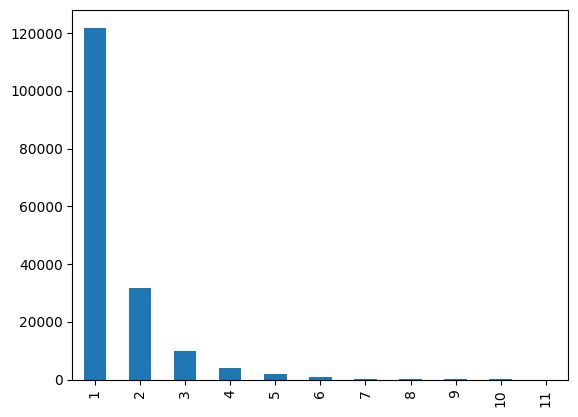

In [7]:
# Get grid shapes from sdata, and add grid_id to the grid shapes
grid_df = sdata.shapes['Visium_HD_Mouse_Brain_square_008um']
grid_df['grid_id'] = grid_df.index

# Create intersection between grid and nuclei
intersections = gdf.overlay(grid_df, how='intersection')
intersections["nucleus_area"] = intersections.geometry.area  # Calculate intersection area

# Calculate percentage of nucleus area over total grid area
grid_area = grid_df.geometry.area.values[0] # 853
intersections["nucleus_area_percentage"] = intersections["nucleus_area"] / grid_area

# What is the number of nuclei in each grid?
# Plot barplot of intersections.grid_id.value_counts()
nuclei_per_grid = intersections.grid_id.value_counts()
nuclei_per_grid = nuclei_per_grid.groupby(nuclei_per_grid.values).count()
nuclei_per_grid.plot(kind="bar")

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


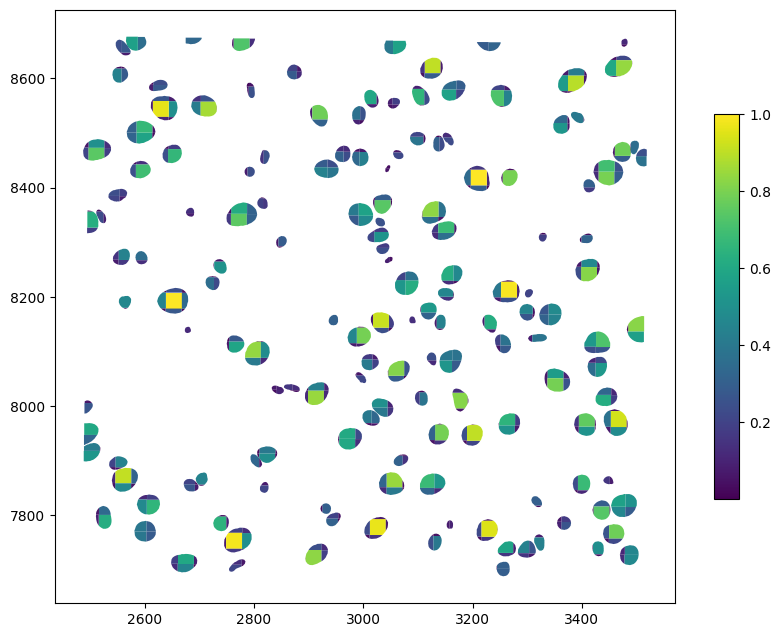

In [38]:
# Let's visualize this on a subset
# Only get intersections that are within the bounding box
bbox=(2496,3500,7700,8664)

intersections_sub = intersections.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
intersections_sub.set_crs("EPSG:3857", inplace=True, allow_override=True) # need to set this or it won't work

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# Color different colors based on the percentage of nucleus area
intersections_sub.plot(column="nucleus_area_percentage", cmap="viridis", legend=False,ax=ax)

# Make legend smaller
cbar = ax.get_legend()
fig.colorbar(ax.collections[0], ax=ax, shrink=0.5, aspect=15)  # Adjust the colorbar with shrink and aspect


In [9]:
# Let's calculate some metrics
import scanpy as sc
sc.pp.calculate_qc_metrics(sdata.tables['square_008um'], inplace=True)

In [10]:
obs_008um_df = sdata.tables['square_008um'].obs
obs_008um_df["spot_id"] = sdata.tables['square_008um'].obs.index

# Combine this with the intersections, to get some statistics per bin
intersections_count = intersections.merge(obs_008um_df, left_on='grid_id', right_on='location_id')

# Remove geometry table, then save to csv
intersections_count = intersections_count.drop(columns='geometry')
intersections_count.to_csv('intersections.csv', index=False)

This is continued in 6_2, to more easily visualize it in ggplot

### 2. Plotting with sparrow

In [11]:
# Add segmentation boundaries to sdata
sdata=sp.sh.add_shapes_layer(
    sdata,
    input=gdf,
    output_layer="segmentation_boundaries",
    overwrite=True,
)

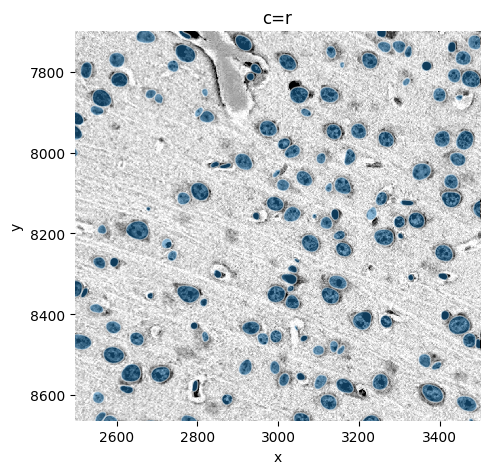

In [12]:
# Let's visualize 
bbox=(2496,3500,7700,8664)

sp.pl.plot_shapes(
    sdata, 
    img_layer="Visium_HD_Mouse_Brain_full_image",
    shapes_layer="segmentation_boundaries",
    crd=bbox,
    figsize=(5,5) ,
    channel="r",
      )

In [13]:
# Add segmentation boundaries as labels
labels_layer = "segmentation_mask"
sdata=sp.im.rasterize( sdata, shapes_layer="segmentation_boundaries", output_layer=labels_layer, overwrite=True )

2024-11-21 17:29:04,786 - sparrow.image._manager - WARNING - No dims parameter specified. Assuming order of dimension of provided array is ((c), (z), y, x)
2024-11-21 17:29:12,131 - sparrow.image._manager - INFO - Writing results to layer 'segmentation_mask'


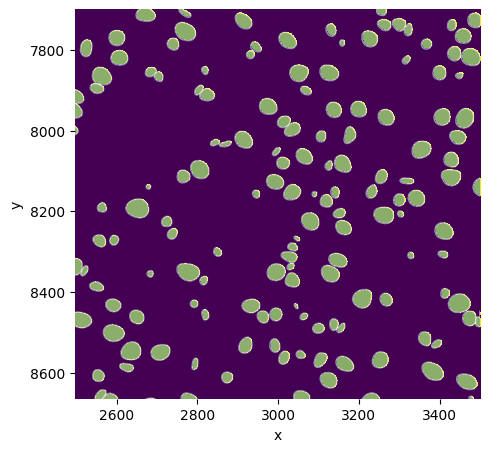

In [14]:
# sanity plot
sp.pl.plot_shapes(
    sdata, 
    labels_layer="segmentation_mask",
    shapes_layer="segmentation_boundaries",
    crd =bbox,
    figsize=(5,5),
    channel="r",
      )

In [13]:
# bin barcodes to the segmentation masks
sdata=sp.tb.bin_counts( 
    sdata,
    table_layer="square_008um",
    labels_layer="segmentation_mask",
    output_layer="table_custom_segmentation_008um",
    append = False,
    overwrite=True,
      )

2024-11-21 12:18:13,849 - sparrow.table._allocation - INFO - Calculating cell counts.
2024-11-21 12:18:14,236 - sparrow.table._allocation - INFO - 
 Number of spots per bin  Frequency
                       1      28809
                       2       5774
                       3        785
                       4        170
                       5          1
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings

In [15]:
sdata

SpatialData object
├── Images
│     ├── 'Visium_HD_Mouse_Brain_full_image': DataTree[cyx] (3, 23947, 18872), (3, 11973, 9436), (3, 5986, 4718), (3, 2993, 2359), (3, 1496, 1179)
│     ├── 'Visium_HD_Mouse_Brain_hires_image': DataArray[cyx] (3, 6000, 4729)
│     └── 'Visium_HD_Mouse_Brain_lowres_image': DataArray[cyx] (3, 600, 473)
├── Labels
│     ├── 'Visium_HD_Mouse_Brain_square_002um_labels': DataArray[yx] (3160, 2508)
│     ├── 'Visium_HD_Mouse_Brain_square_008um_labels': DataArray[yx] (790, 627)
│     ├── 'Visium_HD_Mouse_Brain_square_016um_labels': DataArray[yx] (396, 314)
│     └── 'segmentation_mask': DataArray[yx] (23514, 18668)
├── Shapes
│     ├── 'Visium_HD_Mouse_Brain_square_002um': GeoDataFrame shape: (6296688, 1) (2D shapes)
│     ├── 'Visium_HD_Mouse_Brain_square_008um': GeoDataFrame shape: (393543, 2) (2D shapes)
│     ├── 'Visium_HD_Mouse_Brain_square_016um': GeoDataFrame shape: (98917, 1) (2D shapes)
│     └── 'segmentation_boundaries': GeoDataFrame shape: (82852, 3) 

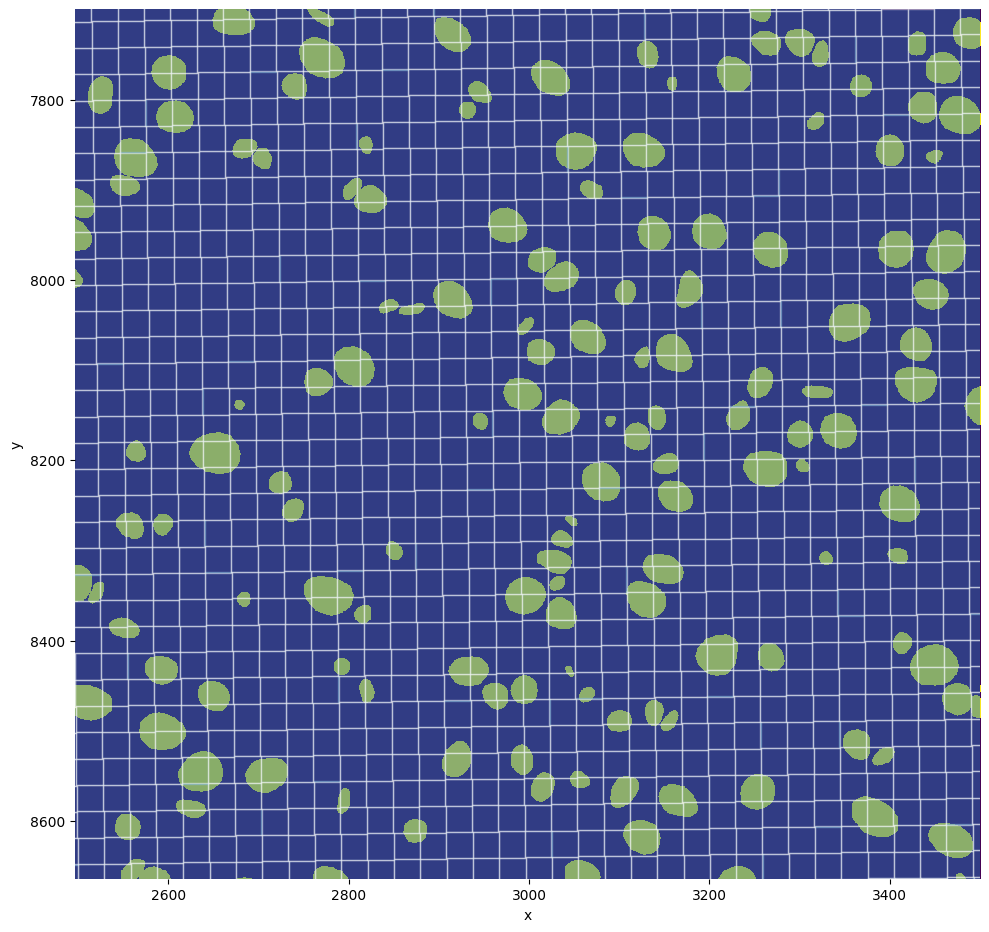

In [27]:
# Visualizing both the grid and segmentation mask
sp.pl.plot_shapes( sdata,
                  shapes_layer= "Visium_HD_Mouse_Brain_square_008um",
                  labels_layer="segmentation_mask",
                  #img_layer="Visium_HD_Mouse_Brain_full_image",
                  to_coordinate_system="global",
                  crd =bbox,
                  channel="r",
                  figsize=(10,10),
                  linewidth=1,
                  table_layer="square_008um")

